## Question 4: LSTMs, GRUs & Context (Air Quality)

In [1]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, Subset
from torch import nn
import os
import pandas as pd
import matplotlib.pyplot as plt
from time import time

torch.manual_seed(42)
device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using device: {device}")

Using device: mps


### Dataset and Utility Classes

In [2]:
class TimeSeriesDataset(Dataset):
    """
    Dataset for Delhi AQI time series.
    Each sample: (input sequence of length seq_len, target value hop steps ahead)
    """

    def __init__(self, file_path, seq_len, hop, col_name='pm2_5', train_frac=0.7):
        df = pd.read_csv(file_path)
        data = torch.tensor(df[col_name].values, dtype=torch.float32)
        self.input_dim = seq_len
        self.num_features = 1

        # Normalize using training stats only to prevent data leakage
        n_train = int(train_frac * len(data))
        self.data_mean = data[:n_train].mean()
        self.data_std  = data[:n_train].std().clamp(min=1e-8)
        data = (data - self.data_mean) / self.data_std

        self.X = []
        self.y = []

        for i in range(len(data) - seq_len - hop):
            self.X.append(data[i:i+seq_len])
            self.y.append(data[i+seq_len+hop])

        self.X = torch.stack(self.X)
        self.y = torch.stack(self.y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [3]:
class EncoderDecoderDataset(Dataset):
    """
    Dataset for Encoder-Decoder forecasting.
    Each sample: (input sequence of length seq_len, target sequence of length output_seq_len)
    """

    def __init__(self, file_path, seq_len, output_seq_len, col_name='pm2_5', train_frac=0.7):
        df = pd.read_csv(file_path)
        data = torch.tensor(df[col_name].values, dtype=torch.float32)
        self.input_dim = seq_len

        # Normalize using training stats only to prevent data leakage
        n_train = int(train_frac * len(data))
        self.data_mean = data[:n_train].mean()
        self.data_std  = data[:n_train].std().clamp(min=1e-8)
        data = (data - self.data_mean) / self.data_std

        self.X = []
        self.y = []

        for i in range(len(data) - seq_len - output_seq_len):
            self.X.append(data[i:i+seq_len])
            self.y.append(data[i+seq_len:i+seq_len+output_seq_len])

        self.X = torch.stack(self.X)
        self.y = torch.stack(self.y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [4]:
def train_loop(train_loader, val_loader, model, loss_fn, optimizer, max_epochs=100, patience=10):
    """
    Training loop with early stopping.
    Stops training when validation loss does not improve for `patience` consecutive epochs.
    """
    best_val = float('inf')
    no_improve = 0
    best_weights = None

    for epoch in range(max_epochs):
        # --- Training ---
        model.train()
        epoch_train_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.float().to(device)
            preds = model(X_batch)
            loss = loss_fn(preds, y_batch)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            epoch_train_loss += loss.item()
        epoch_train_loss /= len(train_loader)

        # --- Validation ---
        model.eval()
        epoch_val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.float().to(device)
                preds = model(X_batch)
                epoch_val_loss += loss_fn(preds, y_batch).item()
        epoch_val_loss /= len(val_loader)

        if epoch % 10 == 0:
            print(f"Epoch {epoch}: Training Loss: {epoch_train_loss:.4f}, Validation Loss: {epoch_val_loss:.4f}")

        # --- Early stopping ---
        if epoch_val_loss < best_val:
            best_val = epoch_val_loss
            no_improve = 0
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Early stopping at epoch {epoch}. Best Validation Loss: {best_val:.4f}")
                model.load_state_dict(best_weights)
                return None

    return None


def test_loop(test_loader, model, loss_fn):
    """
    Evaluation loop, returns predictions and targets.
    """
    model.eval()
    total_loss = 0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.float().to(device)
            preds = model(X_batch)
            total_loss += loss_fn(preds, y_batch).item()
            all_preds.extend(preds.tolist())
            all_targets.extend(y_batch.tolist())

    total_loss /= len(test_loader)
    print(f"Test Loss (MSE): {total_loss:.4f}")
    return all_preds, all_targets

In [5]:
def count_params(model):
    """Count total trainable parameters using state_dict() as required by the assignment."""
    total = 0
    for name, param in model.state_dict().items():
        total += param.numel()
    return total

### Model Definitions

In [6]:
class LSTMRegressor(nn.Module):
    """
    LSTM-based regression model using PyTorch's nn.LSTM.
    Supports BPTT gradient decay analysis via bptt_decay().
    """

    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.lstm_layer = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.output_layer = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # x: (batch, seq_len) -> add feature dim
        if x.dim() == 2:
            x = x.unsqueeze(-1)
        lstm_out, _ = self.lstm_layer(x)
        # Use the last time step's hidden state
        out = self.output_layer(lstm_out[:, -1, :])
        return out.squeeze(1)

    def bptt_decay(self, seq_len=100, input_dim=1):
        """
        Compute gradient magnitudes at t=0, t=50, t=100 for an untrained LSTM.
        Runs on CPU since MPS does not support retain_grad() on intermediate tensors.
        """
        cpu = torch.device('cpu')
        self.to(cpu)

        hidden_dim = self.lstm_layer.hidden_size
        rand_input = torch.randn(1, seq_len, input_dim, device=cpu)

        h_state = torch.zeros(1, 1, hidden_dim, device=cpu)
        c_state = torch.zeros(1, 1, hidden_dim, device=cpu)
        recorded_hidden = {}

        # Step through sequence one timestep at a time to record hidden states
        for t in range(seq_len):
            x_t = rand_input[:, t:t+1, :]
            _, (h_state, c_state) = self.lstm_layer(x_t, (h_state, c_state))
            h_state.retain_grad()  # Keep gradient for this intermediate tensor
            recorded_hidden[t] = h_state

        # Compute loss and backward pass
        final_out = self.output_layer(h_state.squeeze(0))
        dummy_target = torch.zeros(1, 1, device=cpu)
        loss = nn.MSELoss()(final_out, dummy_target)
        loss.backward()

        # Measure gradient magnitude at key timesteps
        g_t100 = recorded_hidden[99].grad.norm().item()
        g_t50  = recorded_hidden[49].grad.norm().item()
        g_t0   = recorded_hidden[0].grad.norm().item()

        print(f"||dL/dh|| at t=100: {g_t100:.2e}")
        print(f"||dL/dh|| at t=50:  {g_t50:.2e}")
        print(f"||dL/dh|| at t=0:   {g_t0:.2e}")

        self.to(device)
        return recorded_hidden

In [7]:
class GRURegressor(nn.Module):
    """
    GRU-based regression model using PyTorch's nn.GRU.
    """

    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.gru_layer = nn.GRU(input_dim, hidden_dim, batch_first=True)
        self.output_layer = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(-1)
        gru_out, _ = self.gru_layer(x)
        out = self.output_layer(gru_out[:, -1, :])
        return out.squeeze(1)

In [8]:
class EncoderDecoderLSTM(nn.Module):
    """
    Encoder-Decoder LSTM for multi-step sequence forecasting.
    - Encoder: processes the 72-hour input history and produces a context vector.
    - Decoder: uses the context vector autoregressively to predict the next 24 hours.
    """

    def __init__(self, input_dim, hidden_dim, output_dim, forecast_len):
        super().__init__()
        self.encoder_lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        # Decoder uses an LSTMCell for step-by-step generation
        self.decoder_cell = nn.LSTMCell(output_dim, hidden_dim)
        self.projection   = nn.Linear(hidden_dim, output_dim)
        self.forecast_len = forecast_len

    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(-1)

        # Encode entire input sequence; h_n/c_n are the context vectors
        _, (h_n, c_n) = self.encoder_lstm(x)
        h_dec = h_n.squeeze(0)  # (batch, hidden_dim)
        c_dec = c_n.squeeze(0)  # (batch, hidden_dim)

        # Start decoder with the last observed value
        dec_input = x[:, -1, :]  # (batch, 1)

        forecasts = []
        for _ in range(self.forecast_len):
            h_dec, c_dec = self.decoder_cell(dec_input, (h_dec, c_dec))
            step_pred = self.projection(h_dec)   # (batch, 1)
            forecasts.append(step_pred)
            dec_input = step_pred  # autoregressive: feed prediction as next input

        # Stack along time dimension: (batch, forecast_len)
        return torch.stack(forecasts, dim=1).squeeze(-1)

### Dataset Setup

In [9]:
csv_path = os.path.join('..', 'Datasets', 'delhi_aqi_dataset', 'delhi_aqi.csv')

# Dataset for single-step regression (predict PM2.5 at t+24 from 72-hour window)
aqi_dataset = TimeSeriesDataset(csv_path, seq_len=72, hop=24)

# Dataset for multi-step sequence prediction (predict 24-step trajectory)
aqi_seq2seq = EncoderDecoderDataset(csv_path, seq_len=72, output_seq_len=24)

#### **Problem 4.10**: LSTM Gradient Rescue

In [ ]:
# Vanilla RNN BPTT results from Q3.8
rnn_grads = {0: 0.0, 49: 6.76e-21, 99: 4.71e-01}

lstm_model = LSTMRegressor(1, 64, 1).to(device)
lstm_hidden_states = lstm_model.bptt_decay()

||dL/dh|| at t=100: 7.78e-02
||dL/dh|| at t=50:  3.96e-13
||dL/dh|| at t=0:   0.00e+00


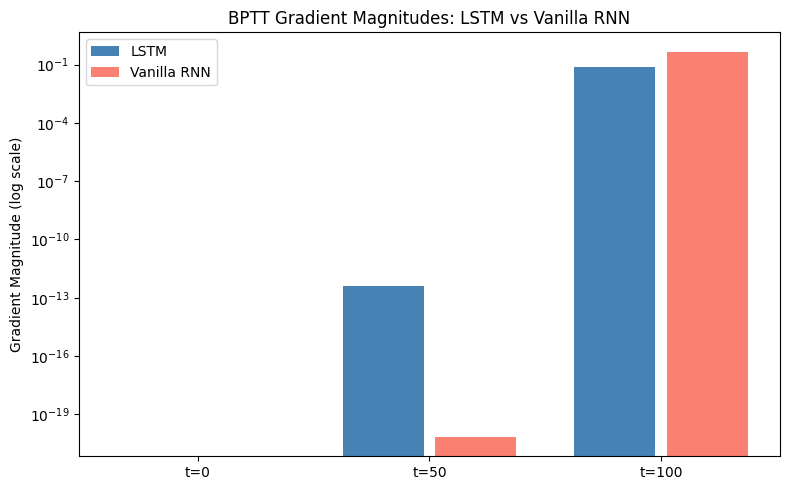

In [11]:
# Plot LSTM gradient magnitudes vs Vanilla RNN
timesteps = [1, 51, 101]  # t=0, t=50, t=100 shown at positions 1, 51, 101
lstm_vals = [
    lstm_hidden_states[0].grad.norm().item(),
    lstm_hidden_states[49].grad.norm().item(),
    lstm_hidden_states[99].grad.norm().item(),
]
rnn_vals = [rnn_grads[0], rnn_grads[49], rnn_grads[99]]

x_labels = ['t=0', 't=50', 't=100']
x_pos = range(3)

plt.figure(figsize=(8, 5))
plt.bar([p - 0.2 for p in x_pos], lstm_vals, width=0.35, label='LSTM', color='steelblue')
plt.bar([p + 0.2 for p in x_pos], rnn_vals,  width=0.35, label='Vanilla RNN', color='salmon')
plt.xticks(x_pos, x_labels)
plt.yscale('log')
plt.ylabel('Gradient Magnitude (log scale)')
plt.title('BPTT Gradient Magnitudes: LSTM vs Vanilla RNN')
plt.legend()
plt.tight_layout()
plt.savefig('bptt_comparison.png', dpi=150)
plt.show()

#### **Problem 4.11**: GRU vs LSTM Efficiency

In [12]:
torch.manual_seed(42)

# Chronological train/val/test split (no shuffling to prevent temporal leakage)
total_samples = len(aqi_dataset)
train_end = int(0.70 * total_samples)
val_end   = int(0.85 * total_samples)

train_idx = list(range(train_end))
val_idx   = list(range(train_end, val_end))
test_idx  = list(range(val_end, total_samples))

train_split = Subset(aqi_dataset, train_idx)
val_split   = Subset(aqi_dataset, val_idx)
test_split  = Subset(aqi_dataset, test_idx)

train_loader = DataLoader(train_split, batch_size=32, shuffle=False)
val_loader   = DataLoader(val_split,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_split,  batch_size=32, shuffle=False)

# Instantiate models with hidden_dim=128
lstm_regressor = LSTMRegressor(1, 128, 1).to(device)
gru_regressor  = GRURegressor(1, 128, 1).to(device)

print(f"LSTM trainable parameters: {count_params(lstm_regressor)}")
print(f"GRU  trainable parameters: {count_params(gru_regressor)}")

LSTM trainable parameters: 67201
GRU  trainable parameters: 50433


In [13]:
mse_loss = nn.MSELoss()
lr = 1e-3
n_epochs = 100

opt_lstm = torch.optim.Adam(lstm_regressor.parameters(), lr=lr)
opt_gru  = torch.optim.Adam(gru_regressor.parameters(), lr=lr)

# Train LSTM and record wall-clock time
t0 = time()
train_loop(train_loader, val_loader, lstm_regressor, mse_loss, opt_lstm, n_epochs, patience=10)
t1 = time()
print(f"LSTM Training Time: {t1 - t0:.2f} seconds")
_,_ = test_loop(test_loader, lstm_regressor, mse_loss)

# Train GRU and record wall-clock time
t2 = time()
train_loop(train_loader, val_loader, gru_regressor, mse_loss, opt_gru, n_epochs, patience=10)
t3 = time()
print(f"GRU  Training Time: {t3 - t2:.2f} seconds")
_,_ = test_loop(test_loader, gru_regressor, mse_loss)

Epoch 0: Training Loss: 0.7641, Validation Loss: 0.2452
Epoch 10: Training Loss: 0.6535, Validation Loss: 0.2725
Early stopping at epoch 10. Best Validation Loss: 0.2452
LSTM Training Time: 48.53 seconds
Test Loss (MSE): 0.9733
Epoch 0: Training Loss: 0.7273, Validation Loss: 0.2432
Epoch 10: Training Loss: 0.6484, Validation Loss: 0.2638
Early stopping at epoch 10. Best Validation Loss: 0.2432
GRU  Training Time: 81.35 seconds
Test Loss (MSE): 0.9702


#### **Problem 4.12**: Sequence-to-Sequence Forecasting

In [14]:
# Dataset splits for seq2seq task
seq2seq_total = len(aqi_seq2seq)
s2s_train_end = int(0.70 * seq2seq_total)
s2s_val_end   = int(0.85 * seq2seq_total)

s2s_train_idx = list(range(s2s_train_end))
s2s_val_idx   = list(range(s2s_train_end, s2s_val_end))
s2s_test_idx  = list(range(s2s_val_end, seq2seq_total))

s2s_train = Subset(aqi_seq2seq, s2s_train_idx)
s2s_val   = Subset(aqi_seq2seq, s2s_val_idx)
s2s_test  = Subset(aqi_seq2seq, s2s_test_idx)

s2s_train_loader = DataLoader(s2s_train, batch_size=32, shuffle=False)
s2s_val_loader   = DataLoader(s2s_val,   batch_size=32, shuffle=False)
s2s_test_loader  = DataLoader(s2s_test,  batch_size=32, shuffle=False)

# Encoder-Decoder model: input_dim=1, hidden_dim=64, output_dim=1, forecast_len=24
seq2seq_model = EncoderDecoderLSTM(1, 64, 1, 24).to(device)

seq2seq_loss = nn.MSELoss()
seq2seq_opt  = torch.optim.Adam(seq2seq_model.parameters(), lr=1e-3)

train_loop(s2s_train_loader, s2s_val_loader, seq2seq_model, seq2seq_loss, seq2seq_opt, max_epochs=100, patience=10)
forecast_preds, forecast_targets = test_loop(s2s_test_loader, seq2seq_model, seq2seq_loss)

Epoch 0: Training Loss: 0.8625, Validation Loss: 0.2446
Epoch 10: Training Loss: 0.5680, Validation Loss: 0.2163
Epoch 20: Training Loss: 0.4634, Validation Loss: 0.2009
Epoch 30: Training Loss: 0.4225, Validation Loss: 0.1967
Epoch 40: Training Loss: 0.4096, Validation Loss: 0.1976
Early stopping at epoch 46. Best Validation Loss: 0.1939
Test Loss (MSE): 0.6882


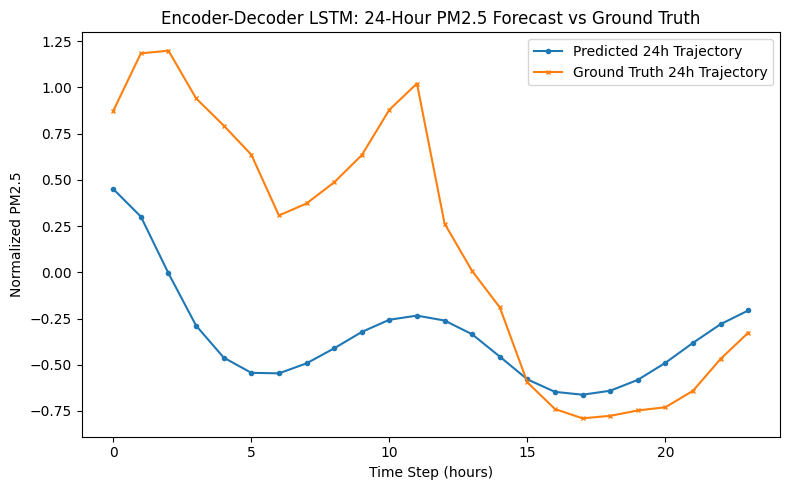

In [ ]:

sample_idx = 1  

plt.figure(figsize=(8, 5))
plt.plot(forecast_preds[sample_idx], label='Predicted 24h Trajectory', marker='o', markersize=3)
plt.plot(forecast_targets[sample_idx], label='Ground Truth 24h Trajectory', marker='x', markersize=3)
plt.xlabel('Time Step (hours)')
plt.ylabel('Normalized PM2.5')
plt.title('Encoder-Decoder LSTM: 24-Hour PM2.5 Forecast vs Ground Truth')
plt.legend()
plt.tight_layout()
plt.savefig('seq2seq_forecast.png', dpi=150)
plt.show()